In [32]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [3]:
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop", "gdppc", "iso3"]
]

In [4]:
def compute_area_weighted_mean(ds, lat_name="lat", lon_name="lon"):
    weights = np.cos(np.deg2rad(ds[lat_name]))
    weights.name = "weights"
    return ds.weighted(weights).mean((lat_name, lon_name))

In [14]:
# Define Forecast Months
fc_months = [8, 9, 10, 11, 12, 1]

In [15]:
## CMIP6 Projections
ar6_project = xr.open_dataset(
    os.path.join(DATA_DIR, "t_CMIP6_ssp370_mon_201501-210012.nc"),
    chunks={"member": -1, "time": -1, "lat": 30, "lon": 30},
)
ar6_hist = xr.open_dataset(
    os.path.join(DATA_DIR, "t_CMIP6_historical_mon_185001-201412.nc"),
    chunks={"member": -1, "time": -1, "lat": 30, "lon": 30},
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/conventions.py:205: SerializationWarning: variable 't' has multiple fill values {np.float32(1.0384594e+34), np.float32(-1.7014118e+38)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/tmp/ipykernel_1654/1641687981.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ar6_project = xr.open_dataset(
/tmp/ipykernel_1654/1641687981.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  ar6_project = xr.open_dataset(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/xarray/conventions.py:205: SerializationWarning: variable 't' has multiple fill values {np.float32(1.0384594e+34), np.float32(-1.7014

In [26]:
# IPCC Recent Baseline Period 1995-2014
hist_mean = (
    ar6_hist["t"]
    .sel(time=slice("1995-01-01", "2014-12-31"))
    .groupby("time.month")
    .mean()
)
hist_mean = hist_mean.mean(dim="member").compute()

In [27]:
projection = ar6_project["t"]
projection = projection.assign_coords(
    year=projection.time.dt.year, month=projection.time.dt.month
)
projection = projection.set_index(time=["year", "month"]).unstack("time")
projection = projection.mean(dim=["member"]).compute()

In [28]:
## Clean statistics
projection = projection.interpolate_na(dim="lat", method="linear")
hist_mean = hist_mean.interpolate_na(dim="lat", method="linear")

In [5]:
POREALLAS_PARSED_ERA5_URI = "gs://poreallas-public-20260605/v20260731/parsed/era5.zarr"
ERA5_RECENT = "/home/emily_zuetell/projects/poreallas/data/parsed/26_era5_daily_running.zarr"
POREALLAS_PARSED_FORECAST_URI = "/home/emily_zuetell/projects/poreallas/data/parsed/08_ecmwf_parsed.zarr"

In [6]:
era5 = xr.load_dataset(
        POREALLAS_PARSED_ERA5_URI,
        engine="zarr",
        backend_kwargs={"storage_options": {"token": "anon"}},
    ).resample(time='MS').mean()
era5_recent = xr.open_zarr(ERA5_RECENT).resample(time='MS').mean().rename({'t2m': 'tas'})
era5_full = xr.merge([era5, era5_recent]) # Original data to 2025, add on recent 2026 ERA5 data

/tmp/ipykernel_1654/4119551829.py:7: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  era5_full = xr.merge([era5, era5_recent]) # Original data to 2025, add on recent 2026 ERA5 data
/tmp/ipykernel_1654/4119551829.py:7: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  era5_full = xr.merge([era5, era5_recent]) # Original data to 2025, add on recent 2026 

In [7]:
forecast = xr.open_zarr(
        POREALLAS_PARSED_FORECAST_URI)

In [8]:
# Baseline period Monthly Climatology
BASELINE_PERIOD = slice("1996-01-01", "2025-12-31")
era5_base = era5.sel(time=BASELINE_PERIOD).groupby('time.month').mean()
forecast_base = forecast.sel(time=BASELINE_PERIOD).groupby('time.month').mean().mean(dim = 'number').compute()

In [29]:
anomaly_proj = projection - hist_mean

In [9]:
### Anomaly
# Analysis Period (1995-2027)
era5_analysis = era5_full.sel(time=slice("1995-01-01", "2026-07-31")).resample(time='MS').mean()
forecast_analysis = forecast.sel(time=slice("2026-08-01", "2027-02-28")).resample(time='MS').mean().compute()

# Subtract Monthly Climatology
era5_anomaly = era5_analysis.groupby('time.month') - era5_base
forecast_anomaly = forecast_analysis.groupby('time.month') - forecast_base

In [55]:
# Pop-Weighted
# Convert Ensemble Average to Impact Regions
era5_ir_anomaly = isku_utils.grid_to_ir(era5_anomaly['tas'])
forecast_ir_anomaly = isku_utils.grid_to_ir(forecast_anomaly['tas'])
cmip6_ir_anomaly = isku_utils.grid_to_ir(anomaly_proj)

merged_era5 = xr.merge([era5_ir_anomaly.rename('anomaly'), socioeconomics])
merged_forecast = xr.merge([forecast_ir_anomaly.rename('anomaly'), socioeconomics])
merged_cmip6 = xr.merge([cmip6_ir_anomaly.rename('anomaly'), socioeconomics])

pop_weighted_anomaly_era5 = (merged_era5['anomaly'] * merged_era5['pop']).sum(dim='region') / merged_era5['pop'].sum(dim='region')
pop_weighted_anomaly_forecast = (merged_forecast['anomaly'] * merged_forecast['pop']).sum(dim='region') / merged_forecast['pop'].sum(dim='region')
pop_weighted_anomaly_cmip6 = (merged_cmip6['anomaly'] * merged_cmip6['pop']).sum(dim='region') / merged_cmip6['pop'].sum(dim='region')

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but succe

In [ ]:
#Reconstruct Time Dimension
da = pop_weighted_anomaly_cmip6
da_time = da.stack(time=("year", "month"))
da_time = da_time.drop_vars(["time", "year", "month"]).assign_coords(
    time=pd.to_datetime(
        [f"{y}-{m:02d}-01" for y, m in zip(da_time.year.values, da_time.month.values)]
    )
).sortby("time")
pop_weighted_anomaly_cmip6 = da_time
pop_weighted_anomaly_cmip6 = pop_weighted_anomaly_cmip6.convert_calendar("noleap", use_cftime=True)

Text(0.5, 1.0, '')

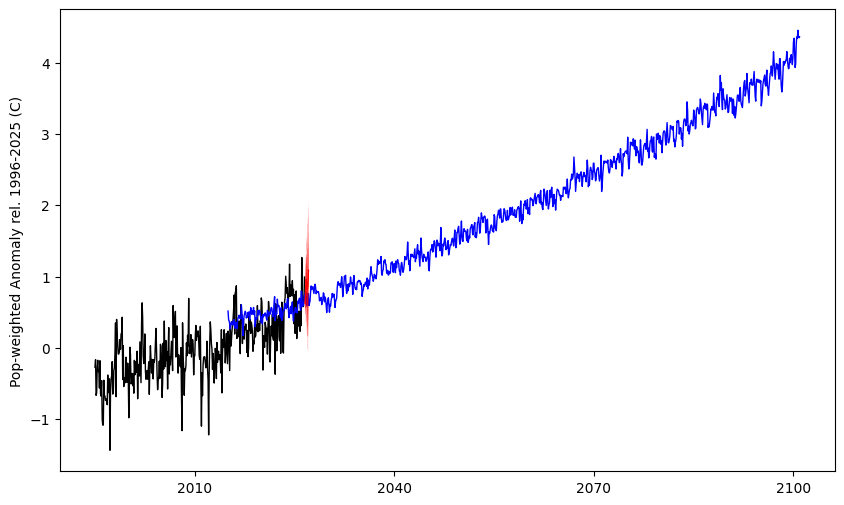

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))
pop_weighted_anomaly_era5.plot(color = 'black', label = 'ERA5(Pop-Weighted)', linewidth = 1, ax = ax)
pop_weighted_anomaly_cmip6.plot(color = 'blue', label = 'CMIP6(Pop-Weighted)', linewidth = 1, ax = ax)

_ = pop_weighted_anomaly_forecast.plot.line(x = 'time', color = 'red', label = 'Forecast(Pop-Weighted)', linestyle = '--', alpha = 0.2, linewidth = 0.2, add_legend=False)
pop_weighted_anomaly_forecast.mean(dim = 'number').plot(color = 'red', label = 'Forecast', linewidth = 1, ax = ax)
ax.set_ylabel('Pop-weighted Anomaly rel. 1996-2025 (C)')
ax.set_xlabel('')
ax.set_title('')
#fig.savefig('timeseries_anomaly_1996_2025.png', dpi = 600, bbox_inches = 'tight')

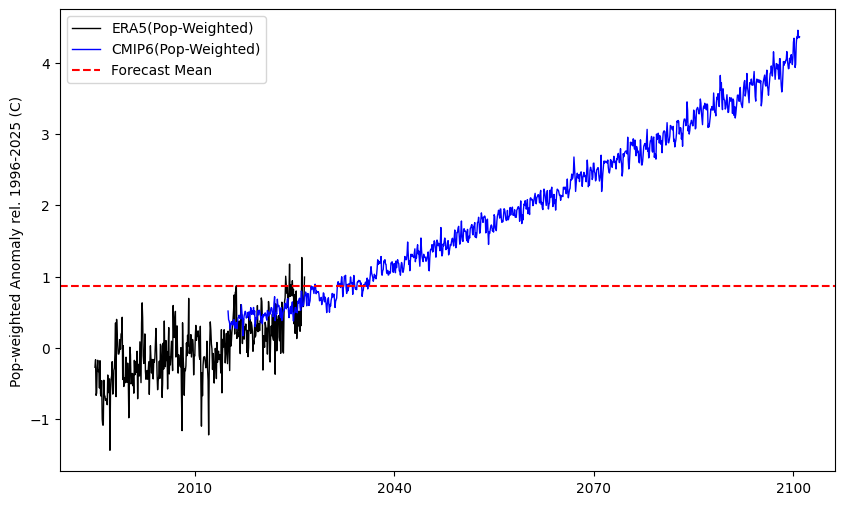

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))
pop_weighted_anomaly_era5.plot(color = 'black', label = 'ERA5', linewidth = 1, ax = ax)
pop_weighted_anomaly_cmip6.plot(color = 'blue', label = 'CMIP6', linewidth = 1, ax = ax)

#_ = pop_weighted_anomaly_forecast.plot.line(x = 'time', color = 'red', label = 'Forecast(Pop-Weighted)', linestyle = '--', alpha = 0.2, linewidth = 0.2, add_legend=False)
plt.axhline(pop_weighted_anomaly_forecast.mean(dim = ['number', 'time']).values, color = 'red', linestyle = '--', label = 'Forecast Mean')
ax.set_ylabel('Pop-weighted Anomaly rel. 1996-2025 (C)')
ax.set_xlabel('')
ax.set_title('')
ax.legend()

In [12]:
pop_weighted_anomaly_era5 = pop_weighted_anomaly_era5.compute()
pop_weighted_anomaly_forecast = pop_weighted_anomaly_forecast.compute()

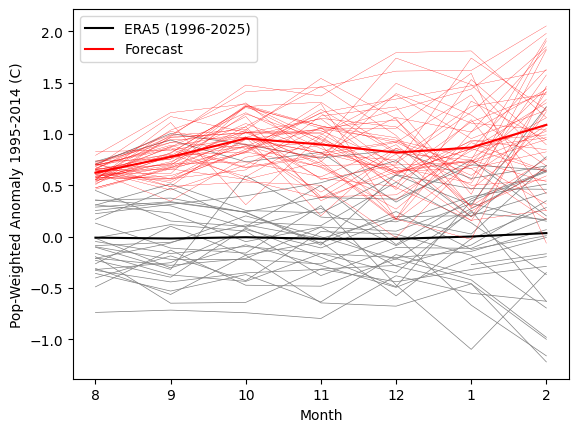

In [13]:
month_order = [8, 9, 10, 11, 12, 1, 2]
month_pos = {m: i for i, m in enumerate(month_order)}

fig, ax = plt.subplots()
month_arr = pop_weighted_anomaly_era5["time"].dt.month
year_arr = pop_weighted_anomaly_era5["time"].dt.year
season_year = xr.where(month_arr >= 8, year_arr, year_arr - 1)

ds_season = pop_weighted_anomaly_era5.assign_coords(season_year=("time", season_year.values))
ds_season = ds_season.sel(time=month_arr.isin(month_order))

for year, group in ds_season.groupby("season_year"):
    g = group.assign_coords(month_idx=("time", [month_pos[m] for m in group["time"].dt.month.values]))
    g.swap_dims({"time": "month_idx"}).plot(x="month_idx", color="gray", linewidth=0.5, ax=ax)
ds_season_mean = ds_season.groupby(ds_season["time"].dt.month).mean(dim="time")
ds_season_mean = ds_season_mean.rename(month="month_orig")
ds_season_mean = ds_season_mean.assign_coords(month_idx=("month_orig", [month_pos[m] for m in ds_season_mean["month_orig"].values]))
ds_season_mean.swap_dims({"month_orig": "month_idx"}).sortby("month_idx").plot(x="month_idx", color="black", linewidth=1.5, ax=ax, label='ERA5 (1996-2025)')

for i in range(51):
    member = pop_weighted_anomaly_forecast.isel(number=i)
    member = member.assign_coords(month=member["time"].dt.month)
    member = member.assign_coords(month_idx=("time", [month_pos[m] for m in member["month"].values]))
    member.swap_dims({"time": "month_idx"}).plot(x="month_idx", color="red", linewidth=0.2, ax=ax)
fc_mean = pop_weighted_anomaly_forecast.mean(dim = 'number')
fc_mean = fc_mean.assign_coords(month=fc_mean["time"].dt.month)
fc_mean = fc_mean.assign_coords(month_idx=("time", [month_pos[m] for m in fc_mean["month"].values]))
fc_mean = fc_mean.swap_dims({"time": "month_idx"})
fc_mean.plot(x="month_idx", color="red", linewidth=1.5, ax=ax, label = 'Forecast')
ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_order)
ax.set_xlabel("Month")
ax.set_ylabel("Pop-Weighted Anomaly 1995-2014 (C)")
ax.set_title("")
ax.legend()
fig.savefig('annual_anomaly_1995_2014.png', dpi = 600, bbox_inches = 'tight')